In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd

## FASE 1.1 La funcion de Collatz

Definimos una funcion que recibe un numero entero positivo y devuelve
la trayectoria completa hasta llegar a 1.

In [5]:
def collatz(n):
    """Genera la trayectoria de Collatz partiendo desde n."""
    trayectoria = [n]
    while n != 1:
        if n % 2 == 0:
            n = n // 2
        else:
            n = 3 * n + 1
        trayectoria.append(n)
    return trayectoria

sacar informacion de altitud y tiempo de vuelo


In [6]:
def info_collatz(n):
    trayectoria = collatz(n)
    pasos = len(trayectoria) - 1
    maximo = max(trayectoria)
    return pasos, maximo
pasos, maximo = info_collatz(27) #se reemplaza el 27 por cualquier numero para ver sus datos

print("Tiempo de vuelo T(n):", pasos)
print("Altitud máxima A(n):", maximo)

Tiempo de vuelo T(n): 111
Altitud máxima A(n): 9232


## FASE 1.2 grafico de tiempo de vuelo

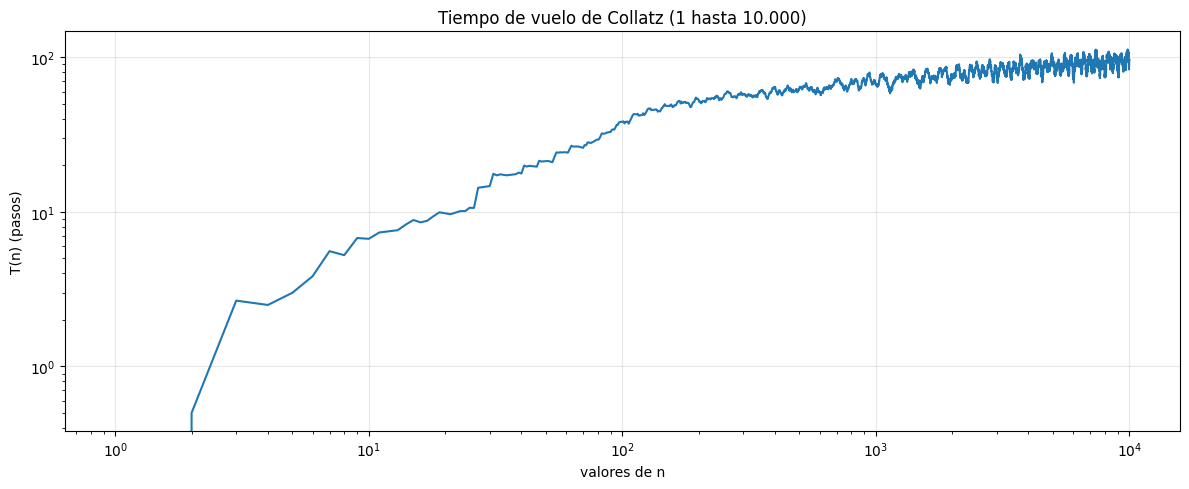

In [7]:
rango = range(1, 10001)

pasos_lista = [len(collatz(n)) - 1 for n in rango]
y_bonita = pd.Series(pasos_lista).rolling(window=75, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(rango, y_bonita)

plt.xlabel("valores de n")
plt.ylabel("T(n) (pasos)")
plt.title("Tiempo de vuelo de Collatz (1 hasta 10.000)")
plt.grid(alpha=0.3)
plt.yscale("log")
plt.xscale("log")

plt.tight_layout()
plt.show()

## FASE 1.2 Grafico de altitud maxima

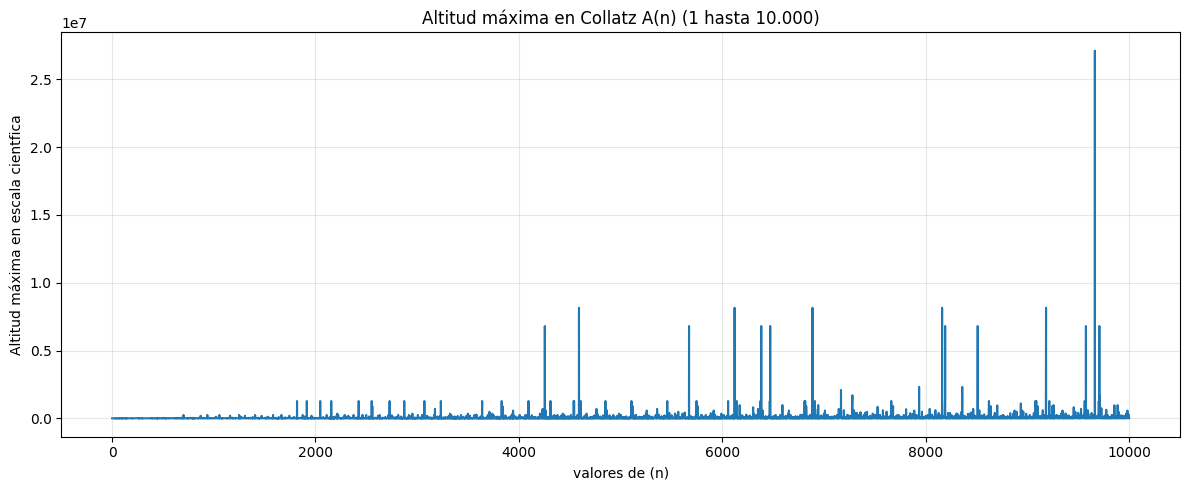

In [8]:

rango = range(1, 10001)

maximos_lista = [max(collatz(n)) for n in rango]

plt.figure(figsize=(12, 5))
plt.plot(rango, maximos_lista)
#partedecorativa
plt.xlabel("valores de (n)")
plt.ylabel("Altitud máxima en escala cientfica")
plt.title("Altitud máxima en Collatz A(n) (1 hasta 10.000)")
plt.grid(alpha=0.3)
#pamostrar
plt.tight_layout()
plt.show()

## FASE 1.3 Graficar T (n) vs n (diagrama de dispersi´on) y el histograma de T(n)

creamos un diagrama de puntos para el primero con rango como x y y como pasos y en el segundo solo evaluamos en x los pasos e y la cantidad de numeros que tuviero ese conteo

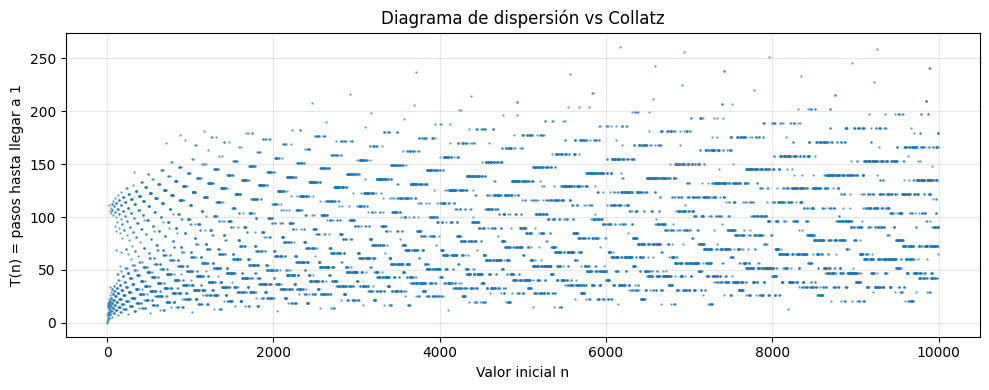

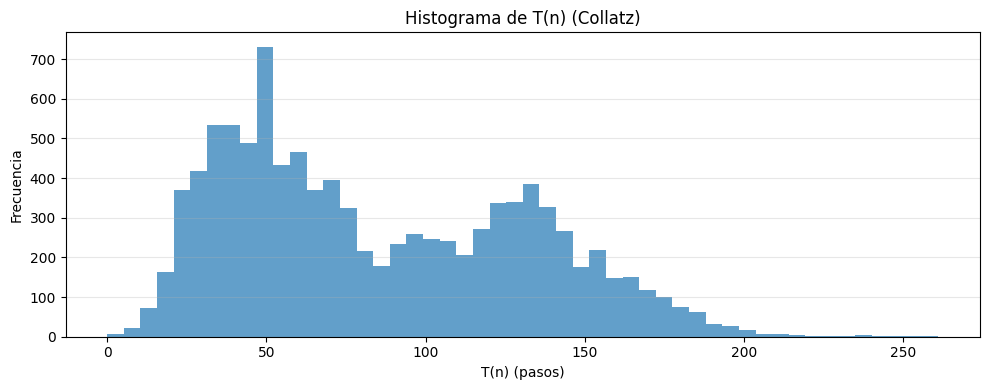

In [14]:
rango = range(1, 10000)
pasos = [len(collatz(n)) - 1 for n in rango] #no estoy seguro porque
#pero tuve que volver a crear la funcion pasos por que no me la tomaba 

# --- DIAGRAMA DE DISPERSIÓN ---
plt.figure(figsize=(10, 4))
plt.scatter(rango, pasos, s=0.5, alpha=0.6)
plt.xlabel("Valor inicial n")
plt.ylabel("T(n) = pasos hasta llegar a 1")
plt.title("Diagrama de dispersión vs Collatz")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- HISTOGRAMA ---
plt.figure(figsize=(10, 4))
plt.hist(pasos, bins=50, alpha=0.7)
plt.xlabel("T(n) (pasos)")
plt.ylabel("Frecuencia")
plt.title("Histograma de T(n) (Collatz)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



## FASE 1.4 Tiempo de vuelo para $n = 1, 2, \ldots, 10000$


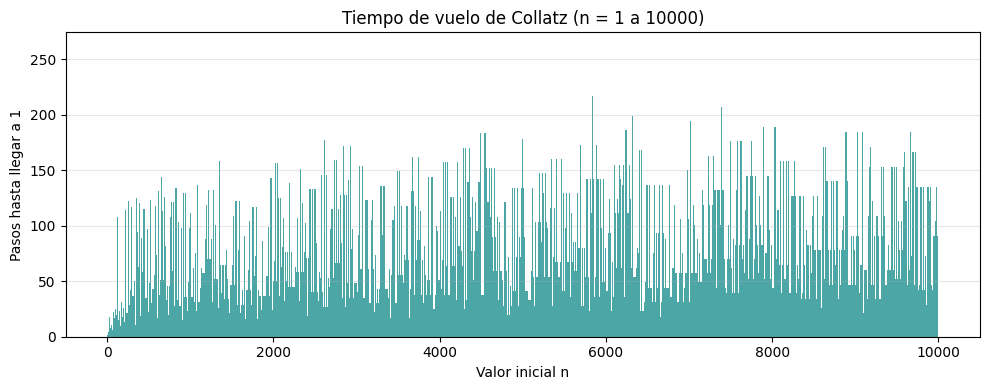

Top 10 números con más pasos en Collatz:
1. n = 6171 → 261 pasos
2. n = 9257 → 259 pasos
3. n = 6943 → 256 pasos
4. n = 7963 → 251 pasos
5. n = 8959 → 246 pasos
6. n = 6591 → 243 pasos
7. n = 9887 → 241 pasos
8. n = 9897 → 241 pasos
9. n = 7422 → 238 pasos
10. n = 7423 → 238 pasos


In [ ]:
rango = range(1, 10000)
pasos = [len(collatz(n)) - 1 for n in rango]
#apartado grafico
plt.figure(figsize=(10, 4))
plt.bar(rango, pasos, color="teal", alpha=0.7, width=1.0)
plt.xlabel("Valor inicial n")
plt.ylabel("Pasos hasta llegar a 1")
plt.title("Tiempo de vuelo de Collatz (n = 1 a 10000)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
#funcion para sacar el top 10
datos = list(zip(rango, pasos))

top10 = sorted(datos, key=lambda x: x[1], reverse=True)[:10]

print("Top 10 números con más pasos en Collatz:")
for i, (n, p) in enumerate(top10, 1):
    print(f"{i}. n = {n} → {p} pasos")